In [57]:
import pandas as pd

df = pd.read_csv("../data/powerLoad_Dataset.csv")

# Convert to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set as index
df.set_index('Timestamp', inplace=True)

# Sort (important)
df = df.sort_index()

df.head()

,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
Timestamp,,,,,,,,,
2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31


In [58]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 10000 entries, 2018-01-01 01:00:00 to 2023-06-30 16:00:00
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Power_Load_kW                  10000 non-null  float64
 1   Temperature_C                  10000 non-null  float64
 2   Humidity_%                     10000 non-null  float64
 3   WindSpeed_mps                  10000 non-null  float64
 4   Precipitation_mm               10000 non-null  float64
 5   DayOfWeek                      10000 non-null  int64  
 6   HolidayFlag                    10000 non-null  int64  
 7   Daily_PostDispatch_Load        10000 non-null  float64
 8   Weekly_PreDispatch_Projection  10000 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 781.2 KB


,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,499.397814,25.022674,60.126286,7.516845,0.202565,3.982500,0.285400,500.112020,509.946114
std,49.880756,7.026358,17.334169,4.346676,0.204053,2.010771,0.451627,10.137719,3.916816
min,308.170000,-5.000000,30.000000,0.000000,0.000000,1.000000,0.000000,463.760000,493.590000
25%,465.467500,20.200000,45.077500,3.757500,0.060000,2.000000,0.000000,493.330000,507.370000
50%,499.985000,25.050000,60.230000,7.560000,0.140000,4.000000,0.000000,500.110000,510.030000
75%,532.900000,29.690000,74.960000,11.270000,0.280000,6.000000,1.000000,506.770000,512.570000
max,680.570000,45.000000,89.990000,15.000000,2.160000,7.000000,1.000000,539.850000,538.100000


In [59]:
df.rename(columns={'Humidity_%': 'Humidity_pct'}, inplace=True)

| Code   | Meaning     |
| ------ | ----------- |
| `'D'`  | Daily       |
| `'W'`  | Weekly      |
| `'ME'` | Month End   |
| `'MS'` | Month Start |


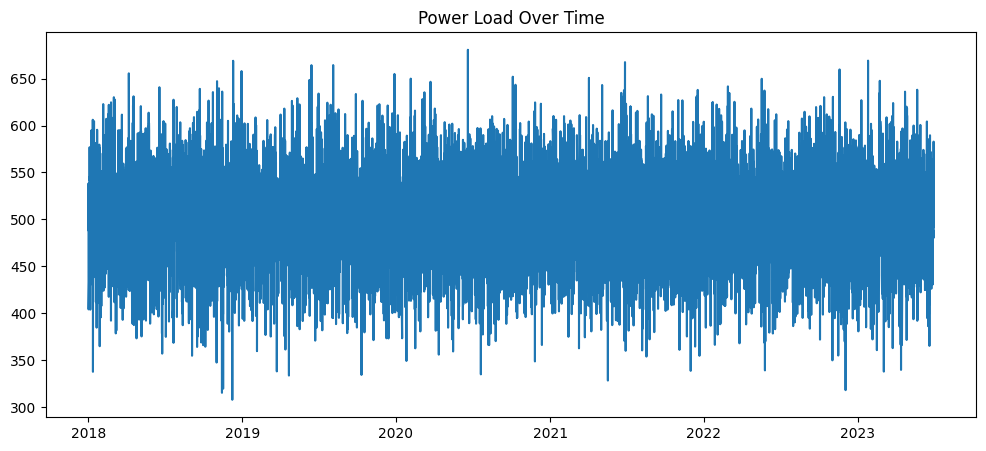

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Power_Load_kW'])
plt.title("Power Load Over Time")
plt.show()

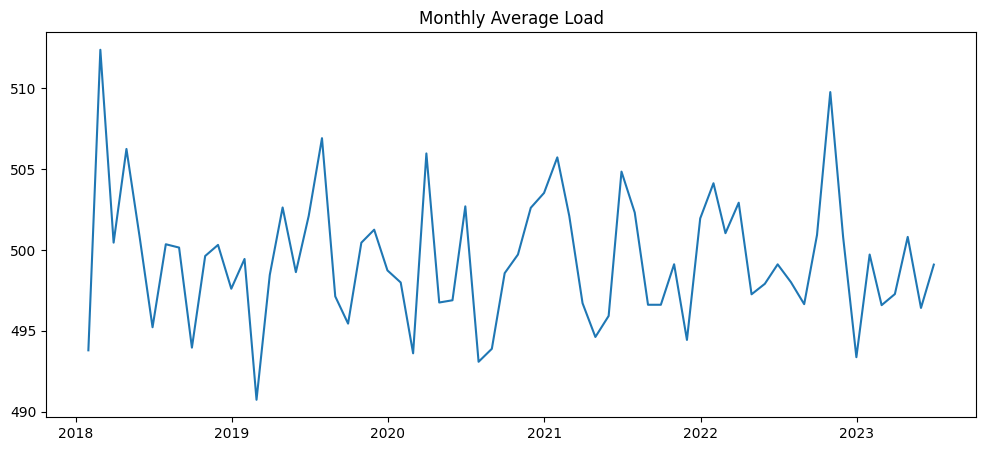

In [61]:
monthly = df['Power_Load_kW'].resample('ME').mean()

plt.figure(figsize=(12,5))
plt.plot(monthly)
plt.title("Monthly Average Load")
plt.show()

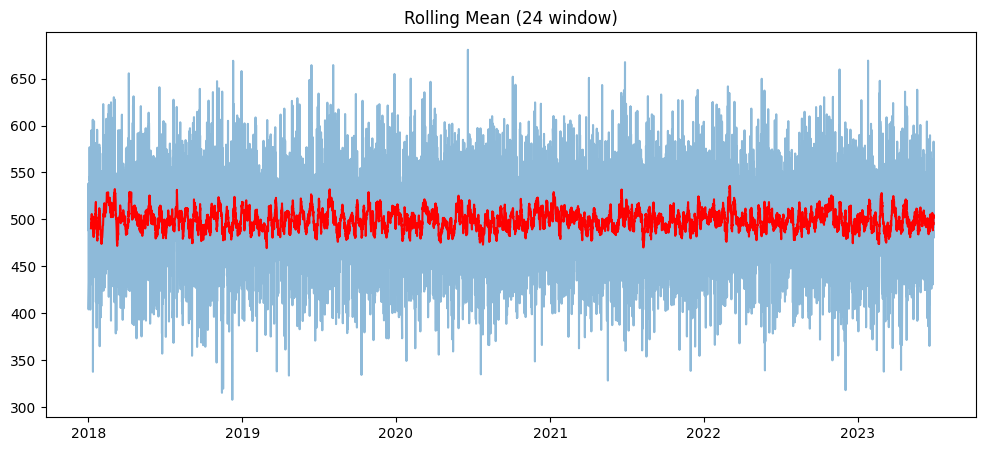

In [62]:
rolling = df['Power_Load_kW'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Power_Load_kW'], alpha=0.5)
plt.plot(rolling, color='red')
plt.title("Rolling Mean (24 window)")
plt.show()

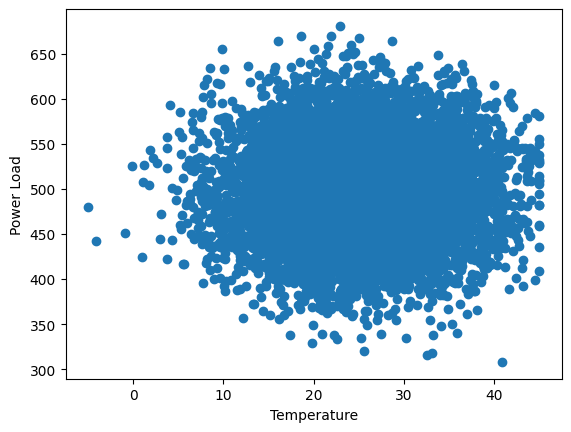

In [63]:
plt.scatter(df['Temperature_C'], df['Power_Load_kW'])
plt.xlabel("Temperature")
plt.ylabel("Power Load")
plt.show()

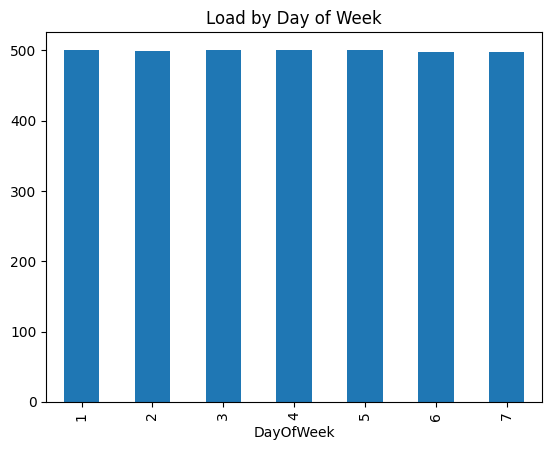

In [64]:
df.groupby('DayOfWeek')['Power_Load_kW'].mean().plot(kind='bar')
plt.title("Load by Day of Week")
plt.show()

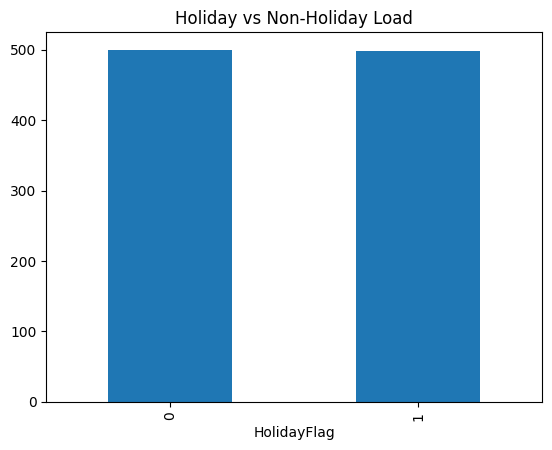

In [65]:
df.groupby('HolidayFlag')['Power_Load_kW'].mean().plot(kind='bar')
plt.title("Holiday vs Non-Holiday Load")
plt.show()

In [66]:
daily = df['Power_Load_kW'].resample('D').mean()

In [67]:
daily.isnull().sum()

np.int64(6)

In [68]:
daily = daily.interpolate()

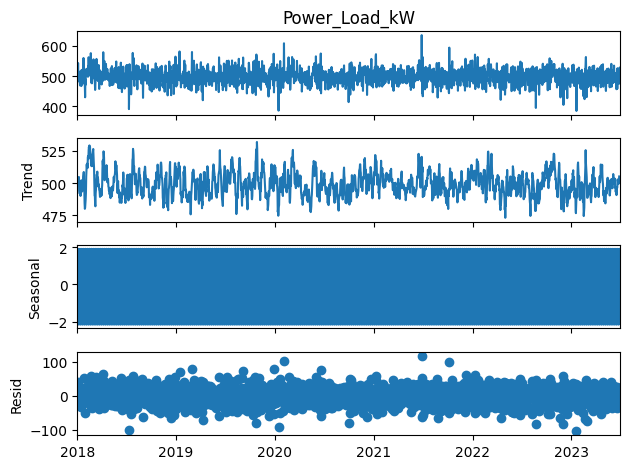

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily, model='additive', period=7)

decomposition.plot()
plt.show()

In [70]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -44.60865135234459
p-value: 0.0


In [71]:
daily_diff = daily.diff().dropna()

In [72]:
result = adfuller(daily_diff)
print("p-value:", result[1])

p-value: 1.0708201489037507e-28


In [73]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily, order=(1,1,1))   # (p,d,q)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          Power_Load_kW   No. Observations:                 2007
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9307.905
Date:                Thu, 23 Apr 2026   AIC                          18621.809
Time:                        12:43:01   BIC                          18638.621
Sample:                    01-01-2018   HQIC                         18627.981
                         - 06-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0041      0.022      0.183      0.855      -0.039       0.048
ma.L1         -1.0000      0.093    -10.743      0.000      -1.182      -0.818
sigma2       625.3424     58.253     10.735      0.0

p → autoregression
d → differencing
q → moving average

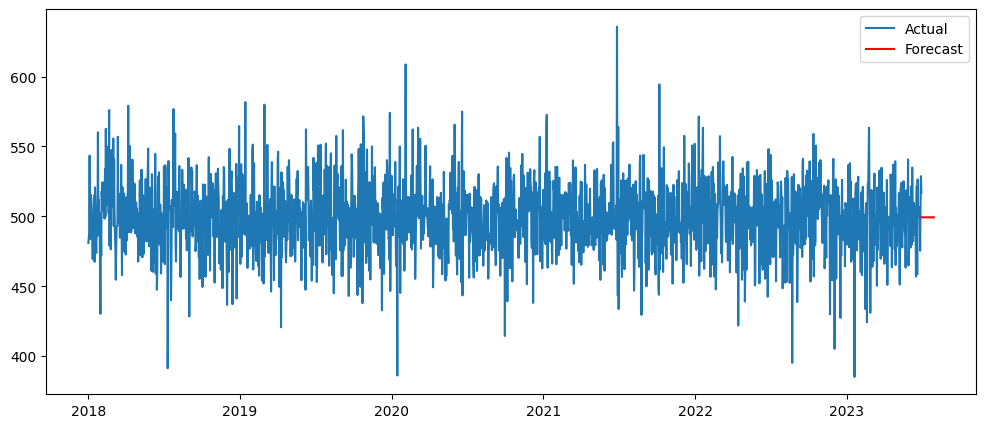

In [74]:
forecast = model_fit.forecast(steps=30)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily, label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()

In [75]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    daily,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

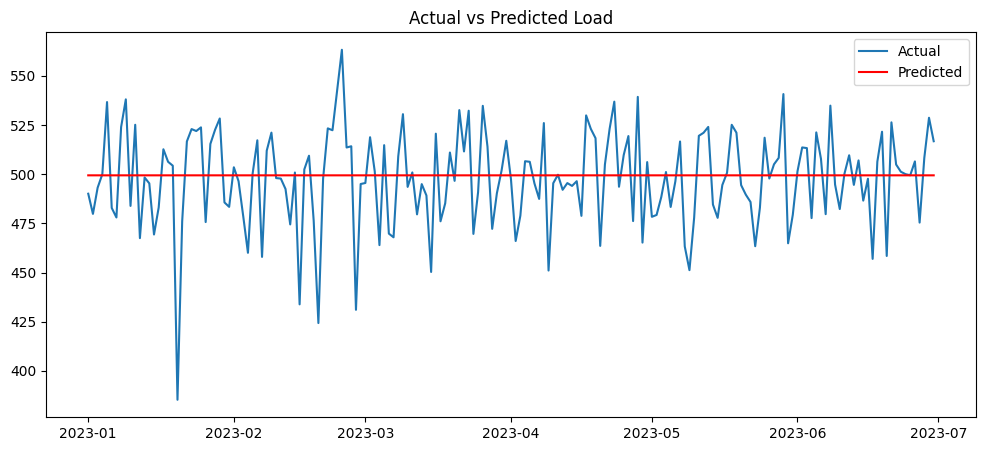

In [76]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred, label='Predicted', color='red')
plt.legend()
plt.title("Actual vs Predicted Load")
plt.show()

In [77]:
exog_features = df[['Temperature_C', 'Humidity_pct']]

model = SARIMAX(
    df['Power_Load_kW'],
    exog=exog_features,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

C:\Users\Dream Unlimited\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Dream Unlimited\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


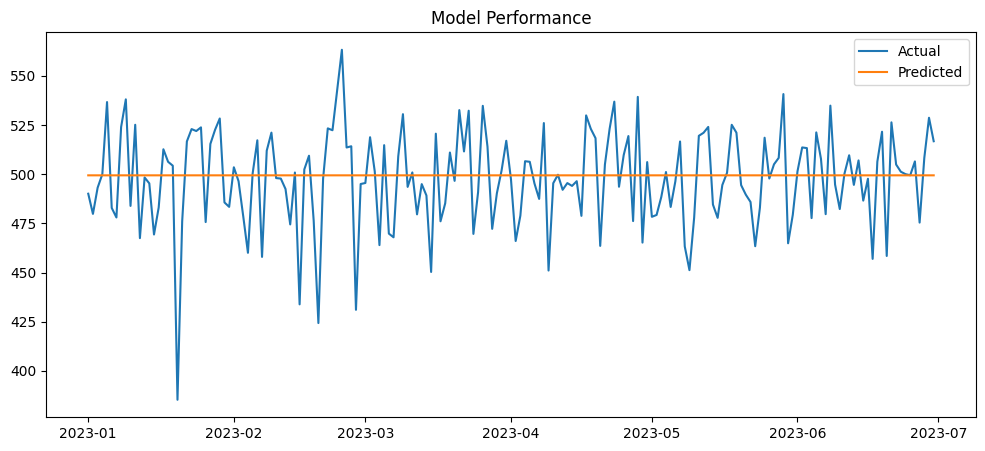

In [78]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred, label='Predicted')
plt.legend()
plt.title("Model Performance")
plt.show()

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 18.702874699140885
RMSE: 24.51537409720564


In [80]:
daily = df['Power_Load_kW'].resample('D').mean()
daily = daily.ffill()


In [81]:
daily.isnull().sum()

np.int64(0)

In [82]:
train = daily[:'2022']
test = daily['2023':]

In [83]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

In [84]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(steps=len(test))

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ARIMA
mae_arima = mean_absolute_error(test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))

# SARIMA
mae_sarima = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))

print("ARIMA -> MAE:", mae_arima, "RMSE:", rmse_arima)
print("SARIMA -> MAE:", mae_sarima, "RMSE:", rmse_sarima)

ARIMA -> MAE: 18.702765032803057 RMSE: 24.51449001331276
SARIMA -> MAE: 18.695857395281177 RMSE: 24.379619800814012


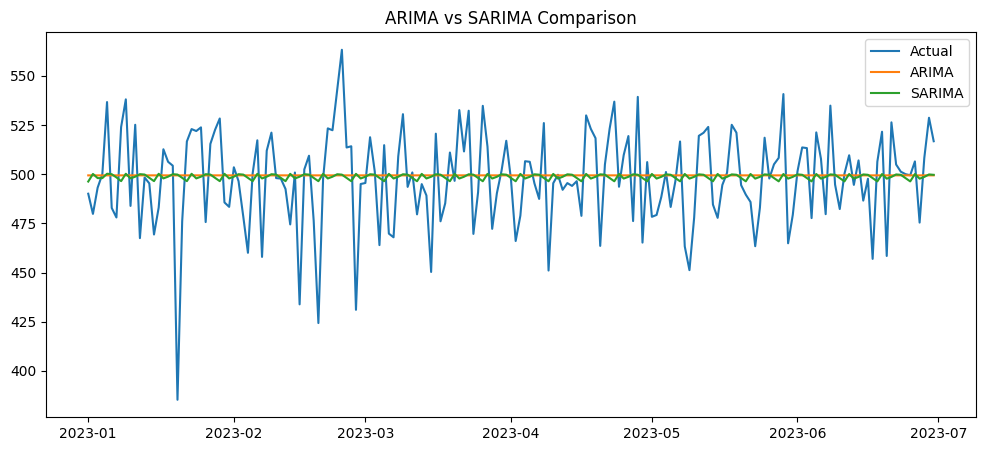

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, sarima_pred, label='SARIMA')

plt.legend()
plt.title("ARIMA vs SARIMA Comparison")
plt.show()

In [87]:
exog = df[['Temperature_C', 'Humidity_pct']].resample('D').mean().ffill()

exog_train = exog.loc[train.index]
exog_test = exog.loc[test.index]

sarimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarimax_fit = sarimax_model.fit()

sarimax_pred = sarimax_fit.forecast(steps=len(test), exog=exog_test)

In [88]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=7,              # weekly seasonality
    d=1,
    D=1,
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[7]             : AIC=inf, Time=3.03 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=19344.379, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=18398.920, Time=0.64 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=2.40 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=18859.218, Time=0.18 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=18198.466, Time=1.40 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=3.89 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=1.36 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=18695.835, Time=0.45 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=17974.055, Time=1.37 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=18171.685, Time=0.96 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=3.91 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=2.51 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=17872.680, Time=2.43 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=18064.262, Ti

In [89]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)

model_fit = model.fit()

sarima_pred = model_fit.forecast(steps=len(test))

C:\Users\Dream Unlimited\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Dream Unlimited\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [90]:
mae = mean_absolute_error(test, sarima_pred)
rmse = np.sqrt(mean_squared_error(test, sarima_pred))

print("Optimized SARIMA -> MAE:", mae)
print("Optimized SARIMA -> RMSE:", rmse)

Optimized SARIMA -> MAE: 18.69818638765508
Optimized SARIMA -> RMSE: 24.386946694241736


In [91]:
exog = df[['Temperature_C', 'Humidity_pct']].resample('D').mean().ffill()

exog_train = exog.loc[train.index]
exog_test = exog.loc[test.index]

In [92]:
model = SARIMAX(
    train,
    exog=exog_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)

model_fit = model.fit()

sarimax_pred = model_fit.forecast(
    steps=len(test),
    exog=exog_test
)

C:\Users\Dream Unlimited\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Dream Unlimited\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [93]:
for p in range(1,3):
    for q in range(1,3):
        for P in range(0,2):
            for Q in range(0,2):
                try:
                    model = SARIMAX(train,
                                    order=(p,1,q),
                                    seasonal_order=(P,1,Q,7))
                    result = model.fit(disp=False)
                    print(p,q,P,Q,result.aic)
                except:
                    continue

1 1 0 0 18113.11969780139
1 1 0 1 16939.39560152171
1 1 1 0 17641.579055805567
1 1 1 1 16940.49586719361
1 2 0 0 18101.351708472663
1 2 0 1 16941.361111036655
1 2 1 0 17642.137752759172
1 2 1 1 16942.398377013116
2 1 0 0 18114.279130689087
2 1 0 1 16941.194007342943
2 1 1 0 17642.000455839698
2 1 1 1 16942.065888061057
2 2 0 0 18099.079895561976
2 2 0 1 16943.301750760744
2 2 1 0 17644.127970530604
2 2 1 1 16944.383895145795


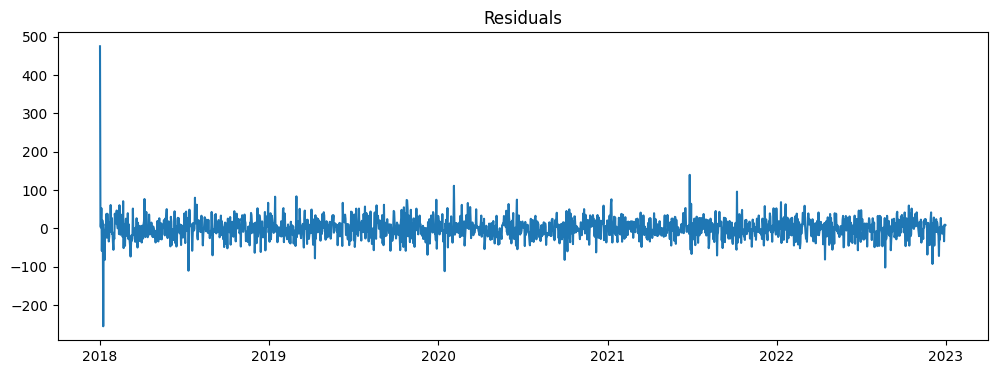

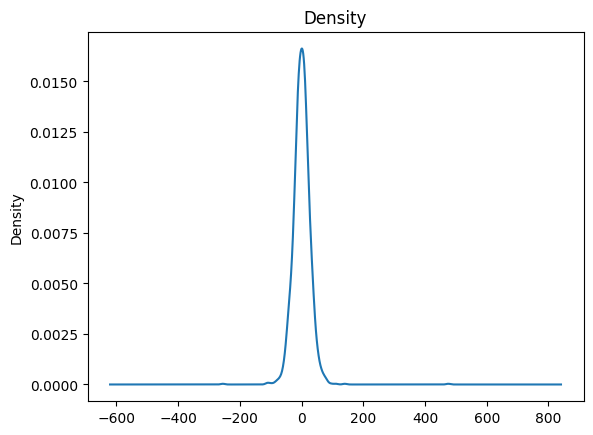

In [94]:
residuals = model_fit.resid

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

residuals.plot(kind='kde', title='Density')
plt.show()

In [95]:
exog = df[['Temperature_C', 'Humidity_pct']].resample('D').mean().ffill()

exog_train = exog.loc[train.index]
exog_test = exog.loc[test.index]

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

model_fit = model.fit()

sarimax_pred = model_fit.forecast(
    steps=len(test),
    exog=exog_test
)

In [97]:
mae = mean_absolute_error(test, sarimax_pred)
rmse = np.sqrt(mean_squared_error(test, sarimax_pred))

print("SARIMAX -> MAE:", mae)
print("SARIMAX -> RMSE:", rmse)

SARIMAX -> MAE: 18.740890186239717
SARIMAX -> RMSE: 24.339068343901502
